Successfully loaded dataset with 400 rows.

--- Model Performance ---
Accuracy Score: 0.88

--- Confusion Matrix ---
[[61  2]
 [10 27]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.97      0.91        63
           1       0.93      0.73      0.82        37

    accuracy                           0.88       100
   macro avg       0.90      0.85      0.86       100
weighted avg       0.89      0.88      0.88       100



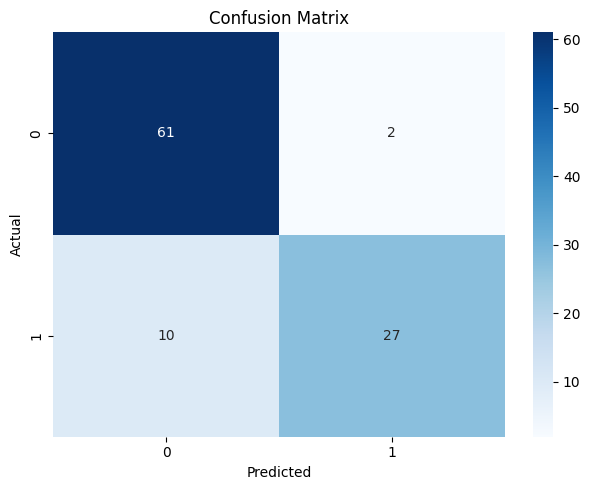

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

# 1. SETUP DATA
# Load your dataset directly
df = pd.read_csv('Social_Network_Ads.csv')
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
# UPDATE THESE: 
# FEATURE_COLS: List of independent variables (must exist in your CSV)
# TARGET_COL: The binary class you want to predict (e.g., 0 or 1, 'Yes' or 'No')
FEATURE_COLS = ['Gender', 'EstimatedSalary','Age'] 
TARGET_COL = 'Purchased'

print(f"Successfully loaded dataset with {len(df)} rows.")

# 2. PREPARE DATA FOR MODELING
X_data = df[FEATURE_COLS]
y_data = df[TARGET_COL]

# Split data into Training and Testing sets (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.25, random_state=42)

# 3. DATA PRE-PROCESSING (Scaling)
# Logistic Regression performs better if features are on the same scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. IMPLEMENT LOGISTIC REGRESSION
model = LogisticRegression()
model.fit(X_train, y_train)

# 5. MAKE PREDICTIONS
y_pred = model.predict(X_test)

# 6. EVALUATE
print("\n--- Model Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 7. VISUALIZE RESULTS
plt.figure(figsize=(12, 5))

# Plot 1: Confusion Matrix Heatmap
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

# Plot 2: Decision Boundary (Only works for exactly 2 features)
if len(FEATURE_COLS) == 2:
    plt.subplot(1, 2, 2)
    # Create a grid to plot decision boundary
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdBu')
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', cmap='RdBu')
    plt.title('Decision Boundary')

plt.tight_layout()
plt.show()